# Train TimeSformer MAE for Threshold Typology Learning

This notebook trains a Masked Autoencoder (MAE) with **asymmetric masking**:
- Frames 0-1 (before): 90% masked
- Frames 2-4 (at threshold): 50% masked (context)
- Frames 5-6 (after): 90% masked

**Goal**: Learn representations by reconstructing heavily-masked before/after frames using threshold context.

## Setup

In [1]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from config_mae import get_mae_config
from timesformer_mae import TimeSformerMAE
from dataset_mae import create_mae_dataloaders
from masking import unpatchify

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## Configuration

In [2]:
# Data path
DATA_ROOT = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data"

# Training hyperparameters
NUM_EPOCHS = 20
BATCH_SIZE = 32
NUM_WORKERS = 4
TRAIN_SPLIT = 0.85

# Resume training
RESUME_FROM = '../models_MAE/output_mae_adjusted/checkpoints/checkpoint_epoch_10.pt'    # '../models_MAE/output_mae/checkpoints/checkpoint_epoch_40.pt'

# Output
OUTPUT_DIR = '../models_MAE/output_mae_adjusted'
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
VIS_DIR = os.path.join(OUTPUT_DIR, 'visualizations')
SAVE_EVERY = 5

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Epochs: 20
  Batch size: 32
  Output: ../models_MAE/output_mae_adjusted


## Create Model

In [3]:
# Get config
config = get_mae_config()

# Create MAE model
model = TimeSformerMAE(config)
model = model.to(device)

print(f"\nModel parameters:")
total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder_blocks.parameters())
decoder_params = sum(p.numel() for p in model.decoder_blocks.parameters())
print(f"  Total: {total_params:,}")
print(f"  Encoder: {encoder_params:,}")
print(f"  Decoder: {decoder_params:,}")

MAE Configuration:
  Image: 32×64, 1 channel(s)
  Patch size: 8×8
  Patches per frame: 32 (4×8)
  Total frames: 7
  Total patches: 224
  Masking strategy: ASYMMETRIC
    Frames 0-1 (before): 90% masked
    Frames 2-4 (at threshold): 50% masked
    Frames 5-6 (after): 90% masked
  Average mask ratio: 72.9%
  Encoder: 6 layers, dim=384
  Decoder: 4 layers, dim=192

Model parameters:
  Total: 12,596,800
  Encoder: 10,646,784
  Decoder: 1,779,456


## Create Data Loaders

In [4]:
train_loader, val_loader, full_dataset, train_indices, val_indices = create_mae_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"Data loaded:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

Found 32 CSV files
Loaded 8046 threshold sequences from 32 files

Dataset split:
  Train samples: 6839
  Val samples: 1207

Data loaded:
  Train batches: 213
  Val batches: 38


## Setup Optimizer

In [5]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.95)
)

# Learning rate scheduler with warmup
def lr_lambda(epoch):
    if epoch < config.warmup_epochs:
        return (epoch + 1) / config.warmup_epochs
    else:
        # Cosine decay after warmup
        progress = (epoch - config.warmup_epochs) / (config.max_epochs - config.warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training state
start_epoch = 0
train_losses = []
val_losses = []
best_val_loss = float('inf')

if RESUME_FROM is not None:
    print(f"Loading checkpoint from: {RESUME_FROM}")
    checkpoint = torch.load(RESUME_FROM, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    if 'train_losses' in checkpoint:
        train_losses = checkpoint['train_losses']
    if 'val_losses' in checkpoint:
        val_losses = checkpoint['val_losses']
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']
    for _ in range(start_epoch):
        scheduler.step()
    print(f"Resuming from epoch {start_epoch}")
else:
    print("Starting fresh training")

print(f"Optimizer: AdamW (lr={config.learning_rate}, wd={config.weight_decay})")
print(f"Scheduler: Warmup {config.warmup_epochs} epochs + Cosine decay")

Loading checkpoint from: ../models_MAE/output_mae_adjusted/checkpoints/checkpoint_epoch_10.pt
Resuming from epoch 10
Optimizer: AdamW (lr=0.00015, wd=0.05)
Scheduler: Warmup 10 epochs + Cosine decay


C:\Users\shrua\AppData\Local\Temp\ipykernel_10508\3864017978.py:39: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


## Training Loop

In [24]:
print("="*80)
print("TRAINING")
print("="*80)
print()

for epoch in range(start_epoch, NUM_EPOCHS):
    # ============ Training ============
    model.train()
    train_loss_epoch = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        imgs = batch['frames'].to(device)  # [B, 7, 1, 32, 64]
        
        # Forward pass with asymmetric masking
        loss, pred, mask = model(imgs, config.frame_mask_ratios)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_epoch += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss_epoch /= len(train_loader)
    train_losses.append(train_loss_epoch)
    
    # ============ Validation ============
    model.eval()
    val_loss_epoch = 0.0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for batch in pbar:
            imgs = batch['frames'].to(device)
            loss, pred, mask = model(imgs, config.frame_mask_ratios)
            val_loss_epoch += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    val_loss_epoch /= len(val_loader)
    val_losses.append(val_loss_epoch)
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {train_loss_epoch:.4f}")
    print(f"  Val Loss:   {val_loss_epoch:.4f}")
    print(f"  LR:         {current_lr:.2e}")
    
    # Save best model
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'config': config,
        }, os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
        print(f"  → Best model saved! (val_loss: {val_loss_epoch:.4f})")
    
    # Save periodic checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'config': config,
        }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pt'))
        print(f"  → Checkpoint saved (epoch {epoch+1})")
    
    print()

print("="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"Best validation loss: {best_val_loss:.4f}")

# Save final model
torch.save({
    'epoch': NUM_EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    'config': config,
}, os.path.join(CHECKPOINT_DIR, 'final_model.pt'))

# Save encoder only
encoder_state = {}
for k, v in model.state_dict().items():
    if k.startswith('encoder') or k.startswith('patch_embed') or 'emb' in k:
        encoder_state[k] = v
torch.save(encoder_state, os.path.join(OUTPUT_DIR, 'encoder_mae_pretrained.pt'))
print(f"Encoder saved to: {os.path.join(OUTPUT_DIR, 'encoder_mae_pretrained.pt')}")

TRAINING



Epoch 11/20 [Train]:   0%|          | 0/213 [00:08<?, ?it/s]

KeyboardInterrupt: 

## Visualize Training Curves

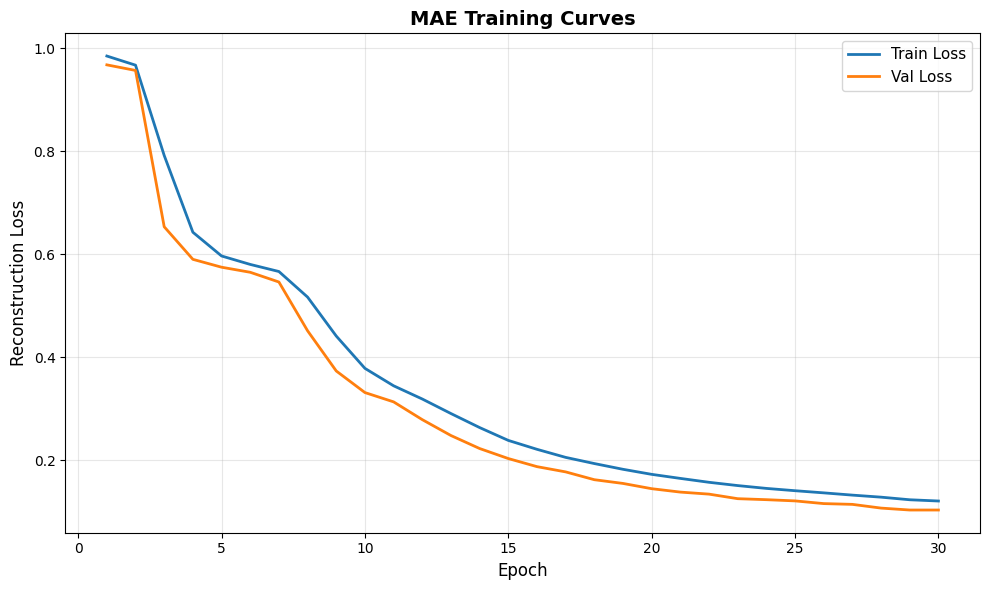

Training curves saved to: ../models_MAE/output_mae_full\training_curves.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = np.arange(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label='Train Loss', linewidth=2)
ax.plot(epochs, val_losses, label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Reconstruction Loss', fontsize=12)
ax.set_title('MAE Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

## Visualize Reconstructions

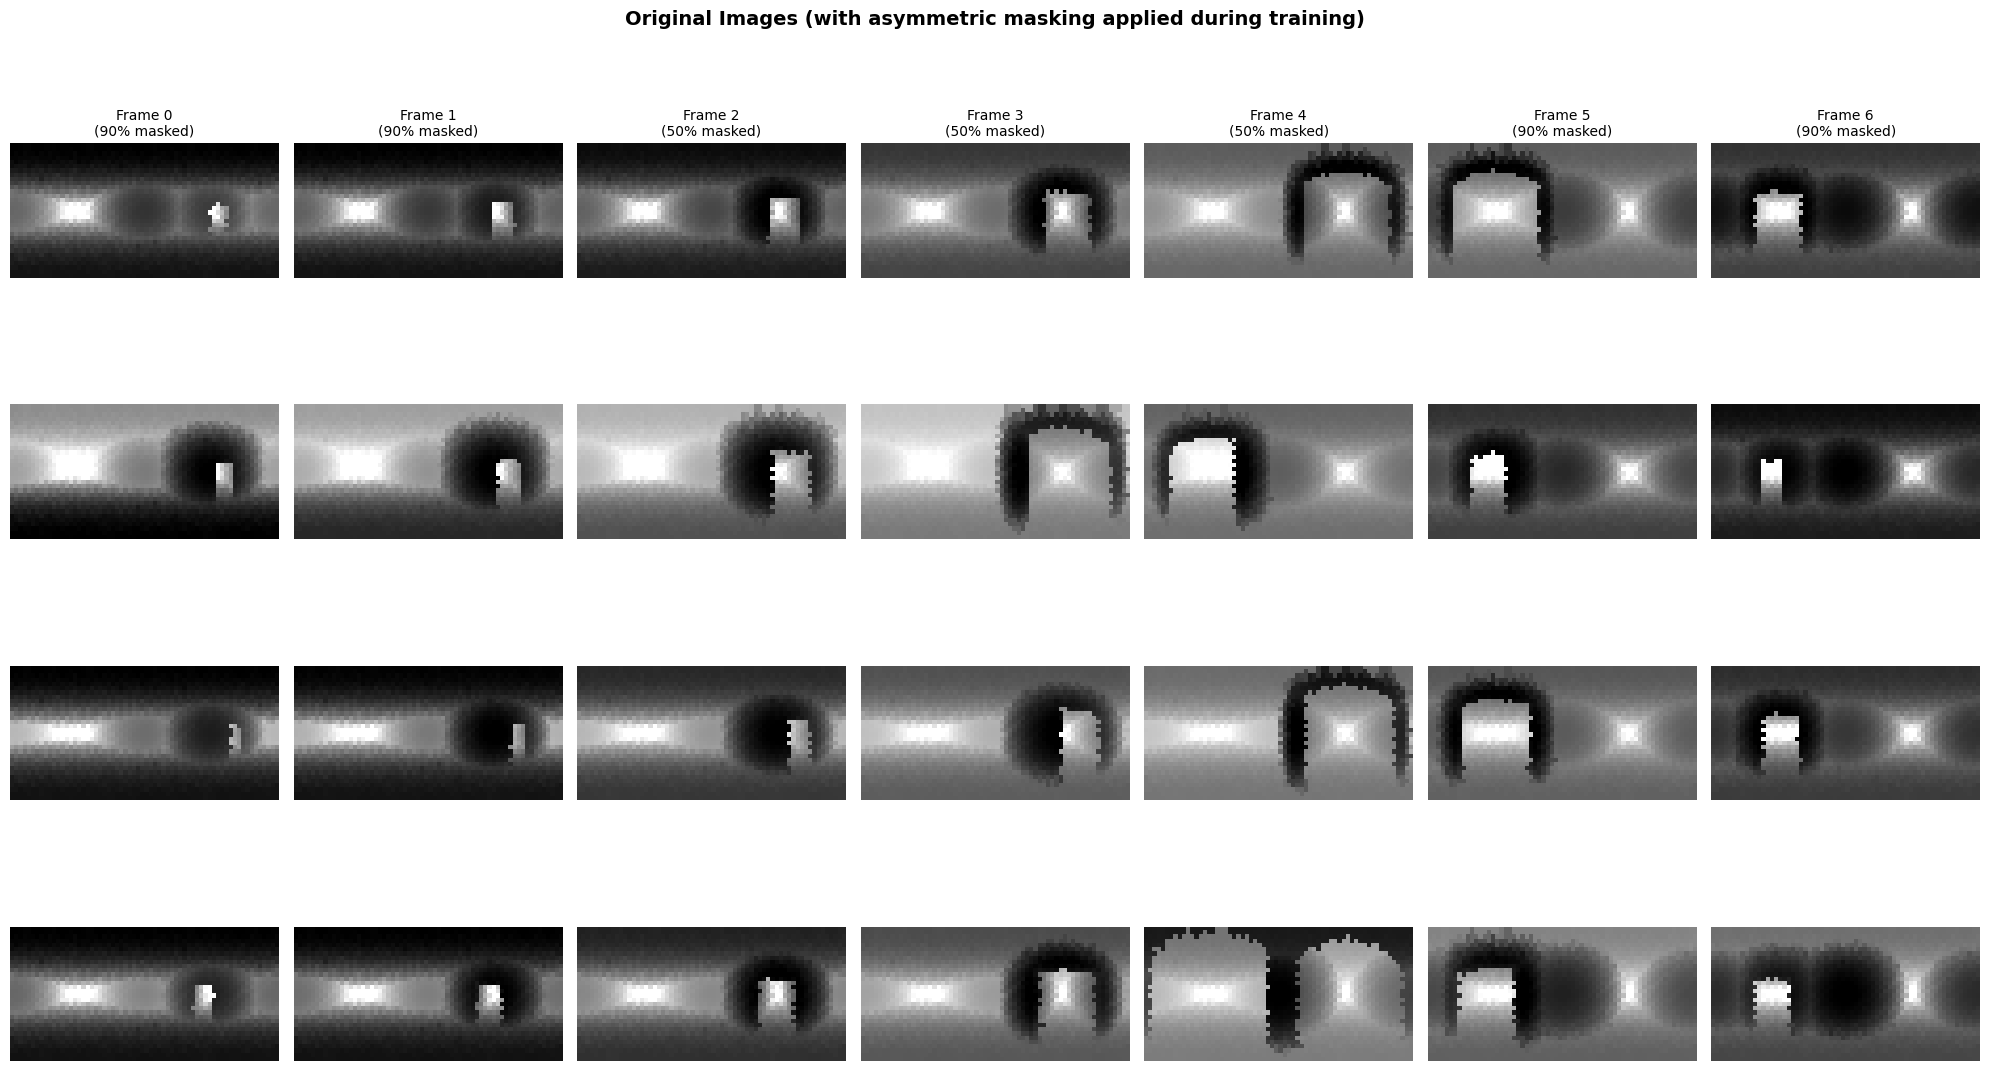

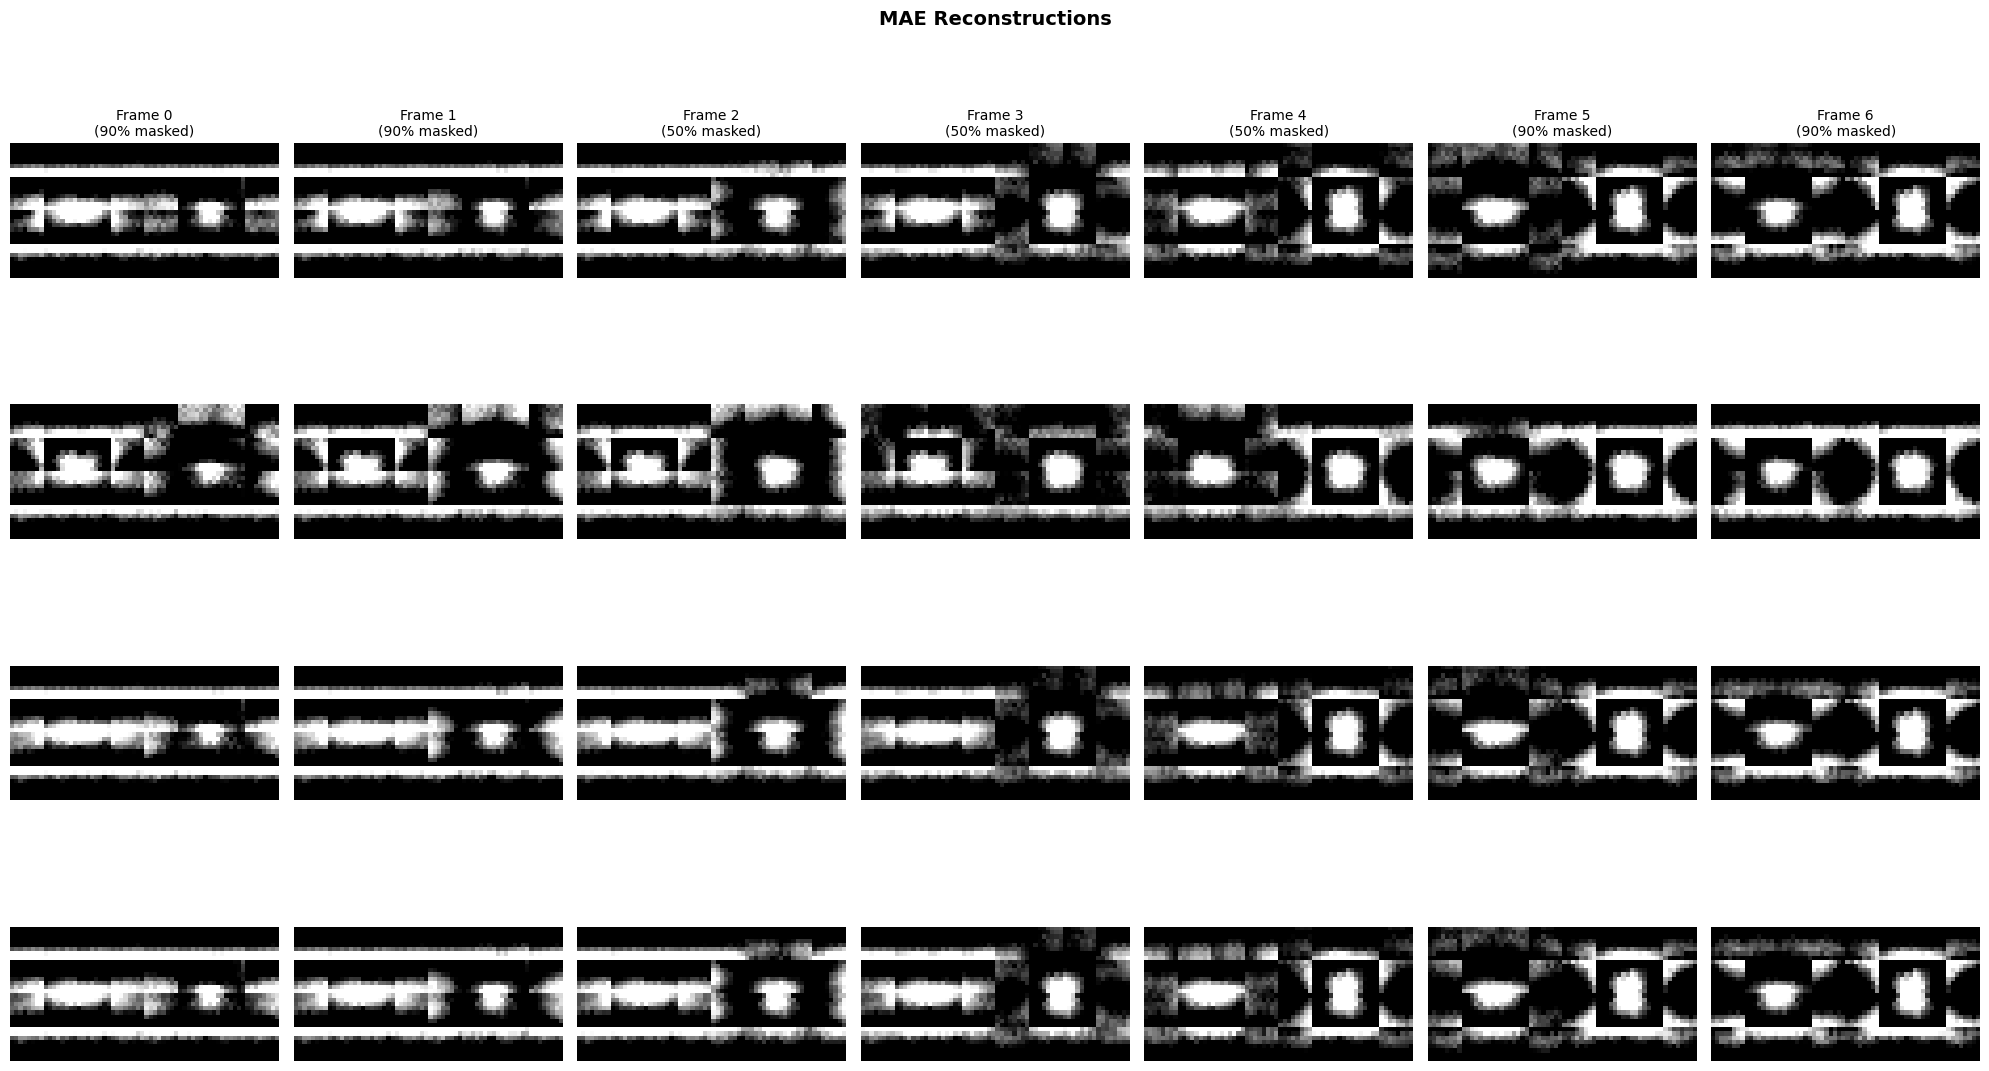

Reconstruction visualizations saved to ../models_MAE/output_mae_adjusted\visualizations


In [6]:
# Load best model
#checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), weights_only=False)
checkpoint = torch.load('../models_MAE/output_mae_adjusted/checkpoints/checkpoint_epoch_10.pt', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get a validation batch
batch = next(iter(val_loader))
imgs = batch['frames'][:4].to(device)  # Take 4 samples

# Forward pass
with torch.no_grad():
    loss, pred, mask = model(imgs, config.frame_mask_ratios)

# Reconstruct images
pred_imgs = unpatchify(
    pred, config.patch_size, config.num_frames, config.num_channels,
    config.image_height, config.image_width
)

# Visualize
fig, axes = plt.subplots(4, 7, figsize=(20, 12))

for i in range(4):
    for t in range(7):
        # Original
        axes[i, t].imshow(imgs[i, t, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i, t].axis('off')
        
        # Show mask info
        mask_ratio = config.frame_mask_ratios[t]
        if i == 0:
            axes[i, t].set_title(f'Frame {t}\n({mask_ratio:.0%} masked)', fontsize=10)

plt.suptitle('Original Images (with asymmetric masking applied during training)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'reconstruction_originals.png'), dpi=150)
plt.show()

# Reconstructions
fig, axes = plt.subplots(4, 7, figsize=(20, 12))

for i in range(4):
    for t in range(7):
        # Reconstruction
        axes[i, t].imshow(pred_imgs[i, t, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i, t].axis('off')
        
        mask_ratio = config.frame_mask_ratios[t]
        if i == 0:
            axes[i, t].set_title(f'Frame {t}\n({mask_ratio:.0%} masked)', fontsize=10)

plt.suptitle('MAE Reconstructions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'reconstruction_predictions.png'), dpi=150)
plt.show()

print(f"Reconstruction visualizations saved to {VIS_DIR}")

## TSNE

In [7]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

print("="*80)
print("EXTRACTING MAE EMBEDDINGS")
print("="*80)
print()

# Load best model
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model (epoch {}, val_loss: {:.4f})".format(
    checkpoint['epoch'], checkpoint['val_loss']))
print()

# Extract embeddings from validation set (no masking!)
embeddings = []
labels = []
typology_names_list = []

print("Extracting embeddings from validation set...")
with torch.no_grad():
    for idx in tqdm(val_indices):
        sample = full_dataset[idx]
        frames = sample['frames'].unsqueeze(0).to(device)  # (1, 7, 1, 32, 64)
        
        # Run encoder WITHOUT masking (pass all zeros for mask ratios)
        x_encoded, _, _ = model.forward_encoder(frames, frame_mask_ratios=(0,0,0,0,0,0,0))
        
        # Global average pooling over all tokens
        h = x_encoded.mean(dim=1)  # (1, 384)
        
        embeddings.append(h.cpu().numpy())
        labels.append(sample['typology_label'])
        typology_names_list.append(sample['metadata']['typology'].split('-')[0])

embeddings = np.concatenate(embeddings, axis=0)  # (N, 384)
labels = np.array(labels)  # (N,)

print(f"\nExtracted {len(embeddings)} embeddings")
print(f"Embedding shape: {embeddings.shape}")
print()

# Analyze typology distribution
print("="*80)
print("TYPOLOGY DISTRIBUTION IN VALIDATION SET")
print("="*80)
unique_labels = np.unique(labels)
unique_typologies = sorted(set(typology_names_list))
print(f"Number of unique typologies: {len(unique_labels)}")
print(f"Unique typology names: {unique_typologies}")
print()

print("Sample counts per typology:")
for typology in unique_typologies:
    count = sum(1 for t in typology_names_list if t == typology)
    sample_idx = typology_names_list.index(typology)
    label_idx = labels[sample_idx]
    print(f"  {typology} (label {label_idx}): {count} samples")
print()

if len(unique_labels) < 8:
    print(f"⚠ WARNING: Only {len(unique_labels)} typologies in validation set!")
else:
    print("✓ All 8 typologies present in validation set")
print()
print("="*80)

EXTRACTING MAE EMBEDDINGS

Loaded best model (epoch 9, val_loss: 0.3534)

Extracting embeddings from validation set...


  0%|          | 0/1207 [00:00<?, ?it/s]


Extracted 1207 embeddings
Embedding shape: (1207, 384)

TYPOLOGY DISTRIBUTION IN VALIDATION SET
Number of unique typologies: 8
Unique typology names: ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

Sample counts per typology:
  t1 (label 0): 154 samples
  t2 (label 1): 151 samples
  t3 (label 2): 161 samples
  t4 (label 3): 127 samples
  t5 (label 4): 148 samples
  t6 (label 5): 158 samples
  t7 (label 6): 172 samples
  t8 (label 7): 136 samples

✓ All 8 typologies present in validation set



In [8]:
# Compute t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) // 4))
embeddings_2d = tsne.fit_transform(embeddings)
print("t-SNE complete")
print()

# Compute clustering metrics
num_clusters = len(unique_labels)
silhouette = silhouette_score(embeddings, labels)

# K-means clustering
print(f"Running K-means with {num_clusters} clusters...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(embeddings)
ari = adjusted_rand_score(labels, pred_labels)

print("="*80)
print("CLUSTERING METRICS")
print("="*80)
print(f"Number of typologies: {num_clusters}")
print(f"Silhouette Score: {silhouette:.3f} (range: -1 to 1, higher is better)")
print(f"Adjusted Rand Index (ARI): {ari:.3f} (range: 0 to 1, higher is better)")
print()

# Interpret results
print("Silhouette Score interpretation:")
if silhouette > 0.3:
    print("  ✓ EXCELLENT! Silhouette > 0.3 indicates good clustering!")
elif silhouette > 0.1:
    print("  ✓ GOOD! Silhouette > 0.1 shows some clustering structure.")
elif silhouette > 0:
    print("  ~ MARGINAL. Silhouette > 0 but weak clustering.")
else:
    print("  ✗ POOR. Negative silhouette indicates random/overlapping clusters.")
print()

print("ARI interpretation:")
if ari > 0.5:
    print("  ✓ EXCELLENT! ARI > 0.5 indicates strong agreement with typologies!")
elif ari > 0.3:
    print("  ✓ GOOD! ARI > 0.3 shows reasonable clustering.")
elif ari > 0.1:
    print("  ~ MARGINAL. ARI > 0.1 but weak agreement.")
else:
    print("  ✗ POOR. ARI near 0 indicates no clustering structure.")

print("="*80)

Computing t-SNE (this may take a minute)...
t-SNE complete

Running K-means with 8 clusters...
CLUSTERING METRICS
Number of typologies: 8
Silhouette Score: 0.348 (range: -1 to 1, higher is better)
Adjusted Rand Index (ARI): 0.856 (range: 0 to 1, higher is better)

Silhouette Score interpretation:
  ✓ EXCELLENT! Silhouette > 0.3 indicates good clustering!

ARI interpretation:
  ✓ EXCELLENT! ARI > 0.5 indicates strong agreement with typologies!


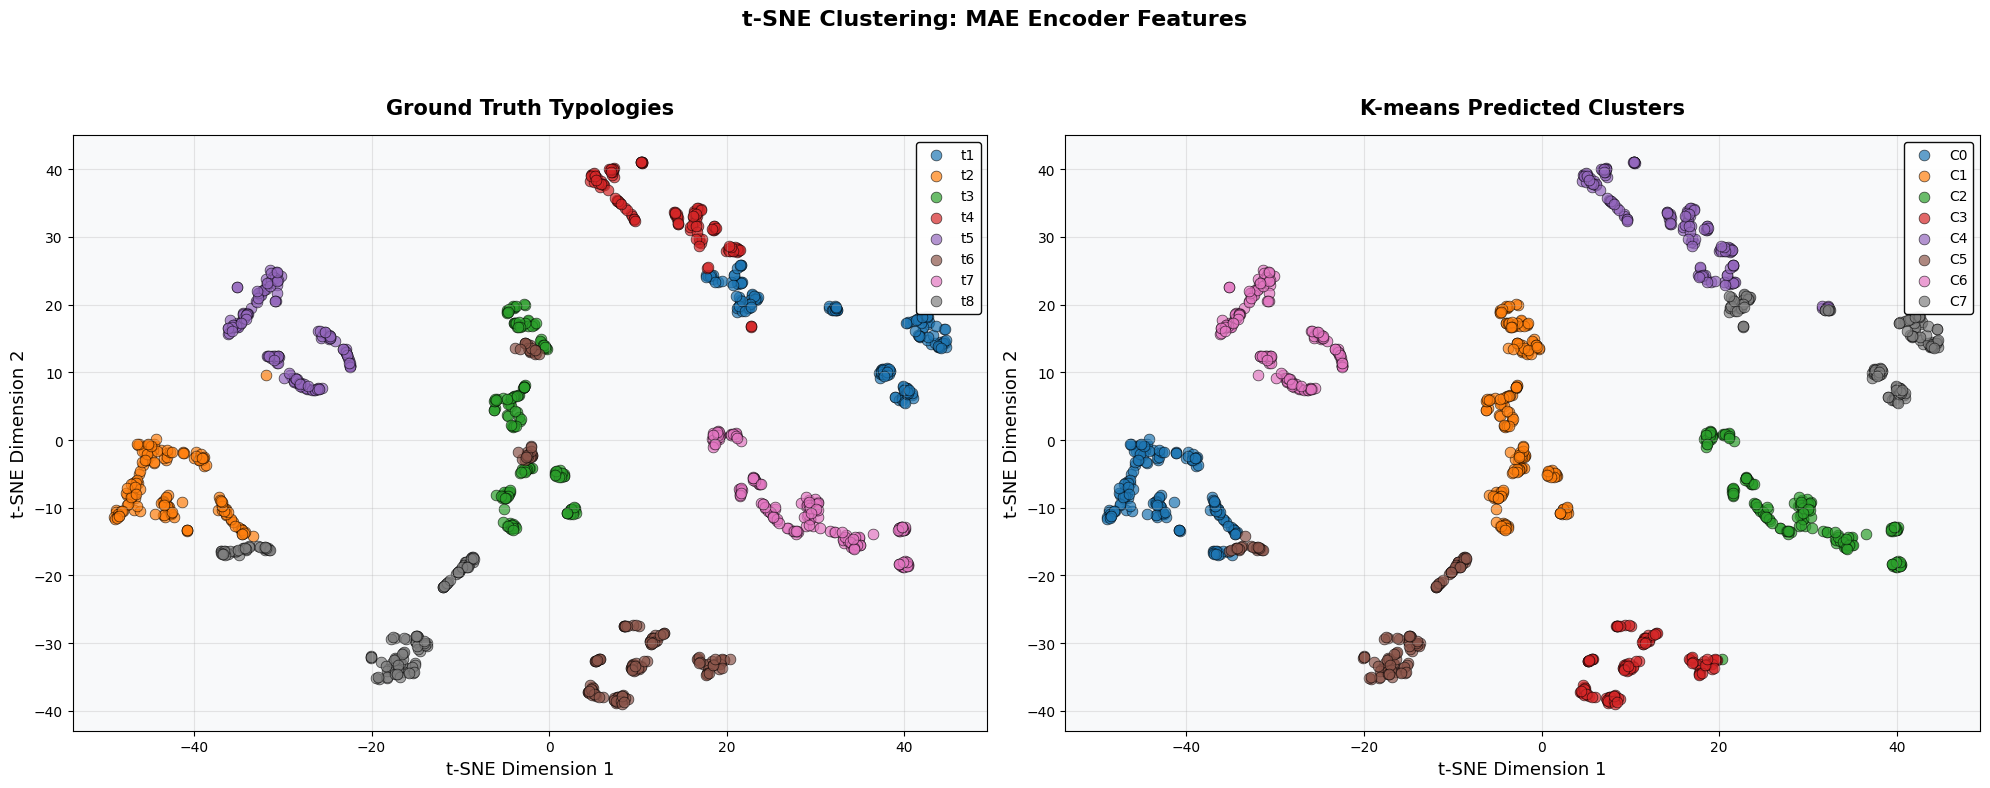


t-SNE plot saved to: ../models_MAE/output_mae_adjusted\tsne_clustering_mae.png

VISUALIZATION GUIDE
LEFT PLOT (Ground Truth):
  - Each color = one typology (t1, t2, ...)
  - Points close together = similar MAE embeddings
  - If MAE learned well, same typology should cluster together

RIGHT PLOT (K-means Predictions):
  - Each color = one predicted cluster
  - Percentage shows cluster purity (% of dominant typology)
  - High purity + good separation = good MAE learning

Silhouette = 0.348:
  → MAE learned excellent typology-distinguishing features!

ARI = 0.856:
  → Strong agreement! Predicted clusters match typologies well.


In [9]:
# Visualize t-SNE: Ground Truth vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Create color map
if num_clusters <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:num_clusters]
else:
    colors = plt.cm.tab20(np.linspace(0, 1, 20))[:num_clusters]

# Create mapping from label to typology name
label_to_name = {}
for i, label in enumerate(labels):
    if label not in label_to_name:
        label_to_name[label] = typology_names_list[i]

# LEFT PLOT: Ground Truth Labels
ax = axes[0]
for i, label_idx in enumerate(unique_labels):
    mask = labels == label_idx
    typology_name = label_to_name[label_idx]
    count = np.sum(mask)
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=f'{typology_name}',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'Ground Truth Typologies',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# RIGHT PLOT: Predicted Clusters (K-means)
ax = axes[1]
unique_pred_labels = np.unique(pred_labels)
for i, pred_label_idx in enumerate(unique_pred_labels):
    mask = pred_labels == pred_label_idx
    count = np.sum(mask)
    # Find which ground truth typology is most common in this cluster
    gt_labels_in_cluster = labels[mask]
    most_common_gt = np.bincount(gt_labels_in_cluster).argmax()
    most_common_name = label_to_name[most_common_gt]
    purity = np.sum(gt_labels_in_cluster == most_common_gt) / len(gt_labels_in_cluster) * 100
    
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i % len(colors)]],
        label=f'C{pred_label_idx}',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'K-means Predicted Clusters',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# Overall title with metrics
fig.suptitle(
    f't-SNE Clustering: MAE Encoder Features\n',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clustering_mae.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nt-SNE plot saved to: {os.path.join(OUTPUT_DIR, 'tsne_clustering_mae.png')}")
print()
print("="*80)
print("VISUALIZATION GUIDE")
print("="*80)
print("LEFT PLOT (Ground Truth):")
print("  - Each color = one typology (t1, t2, ...)")
print("  - Points close together = similar MAE embeddings")
print("  - If MAE learned well, same typology should cluster together")
print()
print("RIGHT PLOT (K-means Predictions):")
print("  - Each color = one predicted cluster")
print("  - Percentage shows cluster purity (% of dominant typology)")
print("  - High purity + good separation = good MAE learning")
print()
print(f"Silhouette = {silhouette:.3f}:")
if silhouette > 0.3:
    print("  → MAE learned excellent typology-distinguishing features!")
elif silhouette > 0.1:
    print("  → MAE learned some typology structure.")
else:
    print("  → MAE struggled to learn typology distinctions.")
print()
print(f"ARI = {ari:.3f}:")
if ari > 0.5:
    print("  → Strong agreement! Predicted clusters match typologies well.")
elif ari > 0.3:
    print("  → Moderate agreement. Some clustering structure learned.")
else:
    print("  → Weak agreement. Clusters don't align with typologies.")
print("="*80)

K-MEANS CLUSTERING ACCURACY ASSESSMENT

Confusion matrix shape: (8, 8) (true labels × predicted clusters)

Optimal cluster-to-label mapping (Hungarian algorithm):
  Cluster 0 → t2 (label 1)
  Cluster 1 → t3 (label 2)
  Cluster 2 → t7 (label 6)
  Cluster 3 → t6 (label 5)
  Cluster 4 → t4 (label 3)
  Cluster 5 → t8 (label 7)
  Cluster 6 → t5 (label 4)
  Cluster 7 → t1 (label 0)

Clustering Accuracy (with optimal matching): 0.928 (92.8%)

Per-typology accuracy:
  t1: 0.786 (78.6%)
  t2: 0.987 (98.7%)
  t3: 1.000 (100.0%)
  t4: 0.976 (97.6%)
  t5: 1.000 (100.0%)
  t6: 0.772 (77.2%)
  t7: 1.000 (100.0%)
  t8: 0.904 (90.4%)



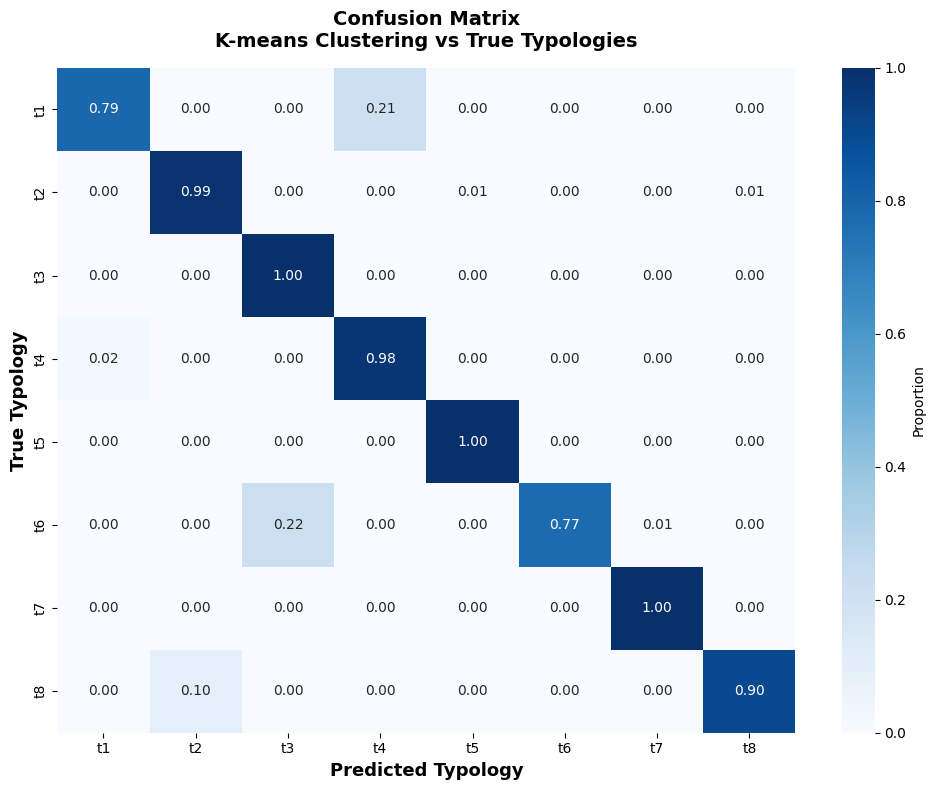

Confusion matrix (proportions) saved to: ../models_MAE/output_mae_adjusted\confusion_matrix_kmeans_proportions.png

CLUSTERING PERFORMANCE SUMMARY
Accuracy:            0.928 (92.8%)
Silhouette Score:    0.348
Adjusted Rand Index: 0.856

Interpretation:
  ✓ EXCELLENT! Accuracy > 70% indicates strong unsupervised clustering!

Note: This is unsupervised clustering accuracy - the encoder was trained
without seeing any typology labels! High accuracy means the MAE encoder
learned representations that naturally separate typologies.


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

print("=" * 80)
print("K-MEANS CLUSTERING ACCURACY ASSESSMENT")
print("=" * 80)
print()

# -----------------------------------------------------------------------------
# Assumed pre-existing variables:
#   labels               : 1D array of true integer labels (shape: [N])
#   pred_labels          : 1D array of predicted K-means cluster IDs (shape: [N])
#   label_to_name        : dict {int_label: "Typology Name"}
#   unique_labels        : sorted list/array of unique integer labels
#   unique_typologies    : list of typology names (strings) you want per-class stats for
#   typology_names_list  : list of typology name for each sample (len N, e.g. ["t1", "t1", "t2", ...])
#   silhouette           : float (silhouette score)
#   ari                  : float (Adjusted Rand Index)
#   OUTPUT_DIR           : folder path to save confusion matrix image
# -----------------------------------------------------------------------------

# ============ Optimal Label Matching using Hungarian Algorithm ============

# Build confusion matrix (rows=true labels, cols=predicted clusters)
cm = confusion_matrix(labels, pred_labels)
print(f"Confusion matrix shape: {cm.shape} (true labels × predicted clusters)")
print()

# Use Hungarian algorithm to find optimal assignment
# We want to maximize the sum of matched elements, so negate for min cost
row_ind, col_ind = linear_sum_assignment(-cm)

# Create mapping from predicted cluster to true label
cluster_to_label = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
print("Optimal cluster-to-label mapping (Hungarian algorithm):")
for cluster_id, true_label in sorted(cluster_to_label.items()):
    typology_name = label_to_name[true_label]
    print(f"  Cluster {cluster_id} → {typology_name} (label {true_label})")
print()

# Map predicted clusters to matched labels
pred_labels_matched = np.array([cluster_to_label.get(c, -1) for c in pred_labels])

# ============ Compute Accuracy ============

accuracy = accuracy_score(labels, pred_labels_matched)
print(f"Clustering Accuracy (with optimal matching): {accuracy:.3f} ({accuracy*100:.1f}%)")
print()

# Per-class accuracy
print("Per-typology accuracy:")
for typology in unique_typologies:
    typology_indices = [i for i, t in enumerate(typology_names_list) if t == typology]
    if len(typology_indices) > 0:
        true_for_typology = labels[typology_indices]
        pred_for_typology = pred_labels_matched[typology_indices]
        typology_acc = accuracy_score(true_for_typology, pred_for_typology)
        print(f"  {typology}: {typology_acc:.3f} ({typology_acc*100:.1f}%)")
print()

# ============ Confusion Matrix Visualization (Proportions) ============

# Normalize rows → each row sums to 1 (proportion by true typology)
cm_matched = confusion_matrix(
    labels,
    pred_labels_matched,
    normalize='true'      # proportions per true label
)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Use typology names for axis tick labels
typology_labels = [label_to_name[i] for i in sorted(unique_labels)]

sns.heatmap(
    cm_matched,
    annot=True,
    fmt='.2f',            # show proportions with 2 decimals
    cmap='Blues',
    xticklabels=typology_labels,
    yticklabels=typology_labels,
    cbar_kws={'label': 'Proportion'},
    ax=ax
)

ax.set_xlabel('Predicted Typology', fontsize=13, fontweight='bold')
ax.set_ylabel('True Typology', fontsize=13, fontweight='bold')
ax.set_title(
    'Confusion Matrix\n'
    'K-means Clustering vs True Typologies',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

os.makedirs(OUTPUT_DIR, exist_ok=True)
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_kmeans_proportions.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion matrix (proportions) saved to: {cm_path}")
print()

# ============ Summary Statistics ============

print("=" * 80)
print("CLUSTERING PERFORMANCE SUMMARY")
print("=" * 80)
print(f"Accuracy:            {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Silhouette Score:    {silhouette:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")
print()

# Interpretation
print("Interpretation:")
if accuracy > 0.7:
    print("  ✓ EXCELLENT! Accuracy > 70% indicates strong unsupervised clustering!")
elif accuracy > 0.5:
    print("  ✓ GOOD! Accuracy > 50% shows reasonable clustering performance.")
elif accuracy > 0.3:
    print("  ~ MODERATE. Accuracy > 30% but room for improvement.")
else:
    print("  ✗ WEAK. Accuracy near random (1/8 = 12.5% for 8 classes).")
print()

print("Note: This is unsupervised clustering accuracy - the encoder was trained")
print("without seeing any typology labels! High accuracy means the MAE encoder")
print("learned representations that naturally separate typologies.")
print("=" * 80)


In [17]:
# ============================================================
# Export t-SNE Coordinates for Illustrator Visualization
# ============================================================

import pandas as pd

print("="*80)
print("EXPORTING t-SNE COORDINATES FOR ILLUSTRATOR")
print("="*80)
print()

# Prepare export data
export_data = []
for i in range(len(embeddings_2d)):
    export_data.append({
        'id': i,
        'x': embeddings_2d[i, 0],
        'y': embeddings_2d[i, 1],
        'true_label': labels[i],
        'typology': typology_names_list[i],
        'kmeans_cluster': pred_labels[i],
        'kmeans_matched': pred_labels_matched[i]
    })

# Convert to DataFrame
export_df = pd.DataFrame(export_data)

# Save to CSV
csv_path = os.path.join(OUTPUT_DIR, 'tsne_coordinates.csv')
export_df.to_csv(csv_path, index=False)
print(f"✓ Saved t-SNE coordinates to: {csv_path}")
print(f"  Total points: {len(export_df)}")
print()

# Print summary
print("Column descriptions:")
print("  id:              Unique ID for each data point")
print("  x, y:            t-SNE 2D coordinates")
print("  true_label:      Ground truth typology label (0-7)")
print("  typology:        Typology name (t1, t2, ..., t8)")
print("  kmeans_cluster:  K-means cluster ID (0-7, arbitrary)")
print("  kmeans_matched:  K-means cluster matched to true label")
print()

# Create mapping reference for Illustrator
print("="*80)
print("ILLUSTRATOR WORKFLOW")
print("="*80)
print()
print("Step 1: Import coordinates")
print("  - Open Illustrator")
print("  - Import tsne_coordinates.csv")
print("  - Use 'x' and 'y' columns for positioning")
print()
print("Step 2: Assign symbols by typology (ground truth)")
print("  Typology → Symbol shape:")
for i, typology in enumerate(sorted(unique_typologies)):
    print(f"    {typology} → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]")
print()
print("Step 3: Fill colors by typology (ground truth)")
print("  Typology → Fill color:")
for i, typology in enumerate(sorted(unique_typologies)):
    rgb = (colors[i % len(colors)][:3] * 255).astype(int)
    hex_color = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
    print(f"    {typology} → {hex_color} (RGB: {rgb[0]}, {rgb[1]}, {rgb[2]})")
print()
print("Step 4: Create legend")
print("  - Symbol shapes = Typology (8 shapes)")
print("  - Symbol colors = Typology (8 colors)")
print("  - Each typology has unique shape AND color")
print()

# Export color palette by typology (ground truth)
palette_data = []
for i, typology in enumerate(sorted(unique_typologies)):
    rgb = (colors[i % len(colors)][:3] * 255).astype(int)
    palette_data.append({
        'typology': typology,
        'hex': f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}",
        'r': rgb[0],
        'g': rgb[1],
        'b': rgb[2]
    })

palette_df = pd.DataFrame(palette_data)
palette_path = os.path.join(OUTPUT_DIR, 'color_palette.csv')
palette_df.to_csv(palette_path, index=False)
print(f"✓ Saved color palette to: {palette_path}")
print()

# Create a simple SVG template with coordinates (colored by GROUND TRUTH)
svg_content = f'''<?xml version="1.0" encoding="UTF-8"?>
<svg xmlns="http://www.w3.org/2000/svg" width="1000" height="1000" viewBox="{embeddings_2d[:, 0].min()-5} {embeddings_2d[:, 1].min()-5} {embeddings_2d[:, 0].max()-embeddings_2d[:, 0].min()+10} {embeddings_2d[:, 1].max()-embeddings_2d[:, 1].min()+10}">
'''

# Add circles for each point (colored by GROUND TRUTH typology)
for i in range(len(embeddings_2d)):
    x, y = embeddings_2d[i]
    true_label = labels[i]  # Use ground truth label instead of predicted
    typology = typology_names_list[i]
    
    # Find the color index for this typology
    typology_idx = sorted(unique_typologies).index(typology)
    rgb = (colors[typology_idx % len(colors)][:3] * 255).astype(int)
    hex_color = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
    
    svg_content += f'  <circle cx="{x}" cy="{y}" r="0.5" fill="{hex_color}" opacity="0.7" data-typology="{typology}" data-label="{true_label}"/>\n'

svg_content += '</svg>'

svg_path = os.path.join(OUTPUT_DIR, 'tsne_layout.svg')
with open(svg_path, 'w') as f:
    f.write(svg_content)

print(f"✓ Saved SVG template to: {svg_path}")
print("  Open in Illustrator and replace circles with custom symbols!")
print("  NOTE: Colors represent GROUND TRUTH typologies")
print()
print("="*80)

EXPORTING t-SNE COORDINATES FOR ILLUSTRATOR

✓ Saved t-SNE coordinates to: ../models_MAE/output_mae_adjusted\tsne_coordinates.csv
  Total points: 1207

Column descriptions:
  id:              Unique ID for each data point
  x, y:            t-SNE 2D coordinates
  true_label:      Ground truth typology label (0-7)
  typology:        Typology name (t1, t2, ..., t8)
  kmeans_cluster:  K-means cluster ID (0-7, arbitrary)
  kmeans_matched:  K-means cluster matched to true label

ILLUSTRATOR WORKFLOW

Step 1: Import coordinates
  - Open Illustrator
  - Import tsne_coordinates.csv
  - Use 'x' and 'y' columns for positioning

Step 2: Assign symbols by typology (ground truth)
  Typology → Symbol shape:
    t1 → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]
    t2 → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]
    t3 → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]
    t4 → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]
    t5 → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]
    t6 → [choose icon, e.g., ■ ● ▲ ◆ ★ ✦ ▼ ◀]
    t7 → [choose icon

## Summary

In [12]:
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print()
print(f"Model: TimeSformer MAE with Asymmetric Masking")
print(f"Epochs trained: {len(train_losses)}")
print(f"Best val loss: {best_val_loss:.4f}")
print()
print("Masking strategy:")
print(f"  Frames 0-1 (before): {config.frame_mask_ratios[0]:.0%} masked")
print(f"  Frames 2-4 (at threshold): {config.frame_mask_ratios[2]:.0%} masked")
print(f"  Frames 5-6 (after): {config.frame_mask_ratios[5]:.0%} masked")
print()
print("Output files:")
print(f"  Best model: {os.path.join(CHECKPOINT_DIR, 'best_model.pt')}")
print(f"  Encoder: {os.path.join(OUTPUT_DIR, 'encoder_mae_pretrained.pt')}")
print(f"  Training curves: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")
print()
print("Next steps:")
print("  1. Fine-tune encoder on classification task")
print("  2. Compare with SimCLR approach")
print("  3. Evaluate t-SNE clustering of MAE features")
print("="*80)

TRAINING SUMMARY

Model: TimeSformer MAE with Asymmetric Masking
Epochs trained: 20
Best val loss: 0.5672

Masking strategy:
  Frames 0-1 (before): 90% masked
  Frames 2-4 (at threshold): 50% masked
  Frames 5-6 (after): 90% masked

Output files:
  Best model: ../models_MAE/output_mae\checkpoints\best_model.pt
  Encoder: ../models_MAE/output_mae\encoder_mae_pretrained.pt
  Training curves: ../models_MAE/output_mae\training_curves.png

Next steps:
  1. Fine-tune encoder on classification task
  2. Compare with SimCLR approach
  3. Evaluate t-SNE clustering of MAE features


# TSNE new

In [15]:
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, 
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score,
    davies_bouldin_score
)
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

print("="*80)
print("EXTRACTING MAE EMBEDDINGS")
print("="*80)
print()

# Load best model
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model (epoch {}, val_loss: {:.4f})".format(
    checkpoint['epoch'], checkpoint['val_loss']))
print()

# Extract embeddings from validation set (no masking!)
embeddings = []
labels = []
typology_names_list = []

print("Extracting embeddings from validation set...")
with torch.no_grad():
    for idx in tqdm(val_indices):
        sample = full_dataset[idx]
        frames = sample['frames'].unsqueeze(0).to(device)  # (1, 7, 1, 32, 64)
        
        # Run encoder WITHOUT masking (pass all zeros for mask ratios)
        x_encoded, _, _ = model.forward_encoder(frames, frame_mask_ratios=(0,0,0,0,0,0,0))
        
        # Global average pooling over all tokens
        h = x_encoded.mean(dim=1)  # (1, 384)
        
        embeddings.append(h.cpu().numpy())
        labels.append(sample['typology_label'])
        typology_names_list.append(sample['metadata']['typology'].split('-')[0])

embeddings = np.concatenate(embeddings, axis=0)  # (N, 384)
labels = np.array(labels)  # (N,)

print(f"\nExtracted {len(embeddings)} embeddings")
print(f"Embedding shape: {embeddings.shape}")
print()

# Analyze typology distribution
print("="*80)
print("TYPOLOGY DISTRIBUTION IN VALIDATION SET")
print("="*80)
unique_labels = np.unique(labels)
unique_typologies = sorted(set(typology_names_list))
print(f"Number of unique typologies: {len(unique_labels)}")
print(f"Unique typology names: {unique_typologies}")
print()

print("Sample counts per typology:")
for typology in unique_typologies:
    count = sum(1 for t in typology_names_list if t == typology)
    sample_idx = typology_names_list.index(typology)
    label_idx = labels[sample_idx]
    print(f"  {typology} (label {label_idx}): {count} samples")
print()

if len(unique_labels) < 8:
    print(f"⚠ WARNING: Only {len(unique_labels)} typologies in validation set!")
else:
    print("✓ All 8 typologies present in validation set")
print()
print("="*80)

EXTRACTING MAE EMBEDDINGS

Loaded best model (epoch 9, val_loss: 0.3534)

Extracting embeddings from validation set...


  0%|          | 0/1207 [00:00<?, ?it/s]


Extracted 1207 embeddings
Embedding shape: (1207, 384)

TYPOLOGY DISTRIBUTION IN VALIDATION SET
Number of unique typologies: 8
Unique typology names: ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

Sample counts per typology:
  t1 (label 0): 154 samples
  t2 (label 1): 151 samples
  t3 (label 2): 161 samples
  t4 (label 3): 127 samples
  t5 (label 4): 148 samples
  t6 (label 5): 158 samples
  t7 (label 6): 172 samples
  t8 (label 7): 136 samples

✓ All 8 typologies present in validation set

